In [2]:
import sys
print(sys.executable)


C:\Users\dudyala guru sreekar\anaconda3\envs\ml_env\python.exe


In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import cv2
import numpy as np

In [12]:
from sklearn.datasets import fetch_openml
import numpy as np
import torch

mnist = fetch_openml('mnist_784', version=1)

X = mnist.data.values.astype(np.float32)
y = mnist.target.values.astype(np.int64)

print("Original pixel range:", X.min(), X.max())

Original pixel range: 0.0 255.0


In [13]:


X = X / 255.0


print("After normalization:", X.min(), X.max())

After normalization: 0.0 1.0


In [14]:
X_tensor = torch.from_numpy(X)
y_tensor = torch.from_numpy(y)

X_tensor = X_tensor.view(-1, 1, 28, 28)

print(X_tensor.shape)


torch.Size([70000, 1, 28, 28])


In [15]:
X_train = X_tensor[:60000]
y_train = y_tensor[:60000]

X_test = X_tensor[60000:]
y_test = y_tensor[60000:]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: torch.Size([60000, 1, 28, 28])
Test shape: torch.Size([10000, 1, 28, 28])


In [16]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

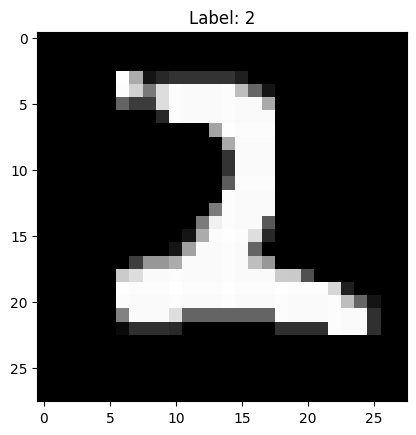

In [17]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

plt.imshow(images[0].squeeze(), cmap='gray')
plt.title(f"Label: {labels[0].item()}")
plt.show()

In [18]:
import torch.nn as nn
import torch.nn.functional as F

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        
        x = x.view(x.size(0), -1)
        
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        
        return x

model = CNN()
print(model)

CNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [19]:
import torch.nn as nn
import torch.optim as optim

model = CNN()

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Model, Loss, Optimizer ready")

Model, Loss, Optimizer ready


In [20]:
epochs =6

for epoch in range(epochs):
    running_loss = 0.0
    
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")

Epoch 1, Loss: 0.2448
Epoch 2, Loss: 0.0612
Epoch 3, Loss: 0.0437
Epoch 4, Loss: 0.0331
Epoch 5, Loss: 0.0259
Epoch 6, Loss: 0.0199


In [21]:
correct = 0
total = 0

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")

Test Accuracy: 98.92%


In [22]:
print("Min pixel:", X_train.min().item())
print("Max pixel:", X_train.max().item())
print("Label dtype:", y_train.dtype)

Min pixel: 0.0
Max pixel: 1.0
Label dtype: torch.int64


In [23]:
import torch.nn.functional as F

images, labels = next(iter(test_loader))

outputs = model(images)
probabilities = F.softmax(outputs, dim=1)

print("Predicted probabilities for first image:")
print(probabilities[0])
print("Predicted digit:", torch.argmax(probabilities[0]).item())
print("True digit:", labels[0].item())

Predicted probabilities for first image:
tensor([4.4775e-11, 2.4353e-07, 1.6677e-08, 1.1565e-06, 1.4150e-10, 1.5006e-09,
        8.1143e-15, 1.0000e+00, 3.0075e-10, 4.3983e-07],
       grad_fn=<SelectBackward0>)
Predicted digit: 7
True digit: 7


In [24]:
import torch

torch.save(model.state_dict(), "digit_model.pth")

In [25]:
import os
print("Current directory:", os.getcwd())
print("Files in folder:", os.listdir())

Current directory: C:\Users\dudyala guru sreekar\AIproject-\MODELS
Files in folder: ['.ipynb_checkpoints', 'digitpredictor.ipynb', 'digit_model.pth', 'digit_model_augmented.pth', 'digit_model_finetuned.pth', 'rotated_test.jpg', 'syn90k .ipynb']


In [26]:
import torch
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.fc1 = nn.Linear(1568, 128)
        self.fc2 = nn.Linear(128, 10)
        
    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = torch.max_pool2d(x, 2)
        x = torch.relu(self.conv2(x))
        x = torch.max_pool2d(x, 2)
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = CNN()
model.load_state_dict(torch.load("digit_model.pth", weights_only=True))
model.eval()

CNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

In [27]:
import torch

dummy = torch.randn(1,1,28,28)

with torch.no_grad():
    output = model(dummy)

print(output.shape)

torch.Size([1, 10])


In [28]:
import cv2
import numpy as np

def preprocess_image(image_path):
   
    img = cv2.imread(image_path)
    if img is None:
        print("Image not found")
        return None

    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Remove noise
    blur = cv2.GaussianBlur(gray, (5,5), 0)

    # Adaptive threshold for uneven lighting
    thresh = cv2.adaptiveThreshold(
        blur,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        11,
        2
    )

    # Find contours
    contours, _ = cv2.findContours(
        thresh,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if not contours:
        print("No digit detected")
        return None

    # Get largest contour (assume digit)
    largest = max(contours, key=cv2.contourArea)

    if cv2.contourArea(largest) < 100:
        print("Detected object too small")
        return None

    x, y, w, h = cv2.boundingRect(largest)
    digit = thresh[y:y+h, x:x+w]

    # Resize to 28x28
    digit = cv2.resize(digit, (28,28))

    # Normalize
    digit = digit / 255.0

    return digit

In [30]:
def preprocess_clean_image(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        return None

    # Resize directly
    img = cv2.resize(img, (28,28))

    # Invert if background is white
    if np.mean(img) > 127:
        img = 255 - img

    img = img / 255.0

    return img

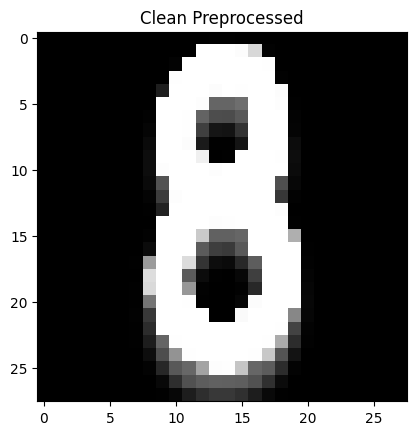

In [31]:
processed = preprocess_clean_image(r"C:/Users/dudyala guru sreekar/Downloads/test.jpg")

plt.imshow(processed, cmap="gray")
plt.title("Clean Preprocessed")
plt.show()

In [32]:
import torch
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.fc1 = nn.Linear(1568, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = torch.max_pool2d(x, 2)
        x = torch.relu(self.conv2(x))
        x = torch.max_pool2d(x, 2)
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [33]:
model = CNN()
model.load_state_dict(torch.load("digit_model.pth", weights_only=True))
model.eval()

print("Model loaded successfully")

Model loaded successfully


In [35]:
import cv2
import numpy as np

img = cv2.imread(r"C:/Users/dudyala guru sreekar/Downloads/test.jpg")

(h, w) = img.shape[:2]
center = (w // 2, h // 2)

M = cv2.getRotationMatrix2D(center, 20, 1.0)
rotated = cv2.warpAffine(img, M, (w, h))

cv2.imwrite("rotated_test.jpg", rotated)

True

In [37]:
from torch.utils.data import DataLoader
from torchvision import transforms
from torch.utils.data import Dataset

# ----------------------------
# 1️⃣ Define Augmentation
# ----------------------------

train_transform = transforms.Compose([
    transforms.RandomRotation(35),   # wider rotation range
    transforms.RandomAffine(
        degrees=0,
        translate=(0.15, 0.15),      # stronger shift
        scale=(0.85, 1.15)           # slight zoom in/out
    ),
])

test_transform = transforms.Compose([])

# ----------------------------
# 2️⃣ Custom Dataset Wrapper
# ----------------------------

class AugmentedDataset(Dataset):
    def __init__(self, X, y, transform=None):
        self.X = X
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        image = self.X[idx]
        label = self.y[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

# ----------------------------
# 3️⃣ Create Augmented Datasets
# ----------------------------

train_dataset = AugmentedDataset(X_train, y_train, transform=train_transform)
test_dataset  = AugmentedDataset(X_test, y_test, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [38]:
torch.save(model.state_dict(), "digit_model_augmented.pth")
print("Augmented model saved")

Augmented model saved


In [40]:
processed = preprocess_clean_image(r"C:/Users/dudyala guru sreekar/Downloads/test.jpg")

print(type(processed))
print(processed.shape if processed is not None else "None")

<class 'numpy.ndarray'>
(28, 28)


In [41]:
tensor = torch.tensor(processed, dtype=torch.float32)
tensor = tensor.unsqueeze(0).unsqueeze(0)

print(tensor.shape)

torch.Size([1, 1, 28, 28])


In [42]:
with torch.no_grad():
    output = model(tensor)

print(output.shape)

torch.Size([1, 10])


In [43]:
probs = F.softmax(output, dim=1)
confidence, predicted = torch.max(probs, 1)

print("Digit:", predicted.item())
print("Confidence:", confidence.item())

Digit: 8
Confidence: 0.9991416931152344


In [44]:
CONF_THRESHOLD = 0.85

def predict_digit(image_path):

    processed = preprocess_clean_image(image_path)

    if processed is None:
        return {"status": "no_digit_detected"}

    tensor = torch.tensor(processed, dtype=torch.float32)
    tensor = tensor.unsqueeze(0).unsqueeze(0)

    with torch.no_grad():
        outputs = model(tensor)
        probs = F.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probs, 1)

    confidence = confidence.item()
    predicted = predicted.item()

    if confidence < CONF_THRESHOLD:
        return {
            "status": "uncertain",
            "confidence": confidence
        }

    return {
        "status": "success",
        "digit": predicted,
        "confidence": confidence
    }

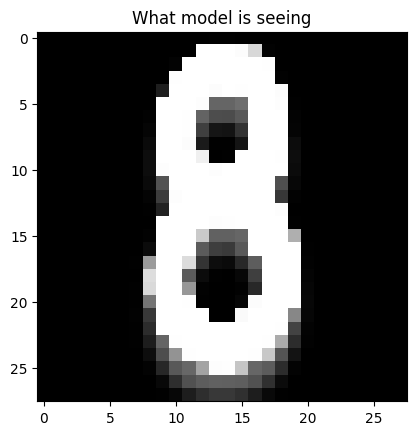

In [45]:
processed = preprocess_clean_image(r"C:/Users/dudyala guru sreekar/Downloads/test.jpg")

import matplotlib.pyplot as plt
plt.imshow(processed, cmap="gray")
plt.title("What model is seeing")
plt.show()

In [46]:
print(predict_digit("rotated_test.jpg"))

{'status': 'success', 'digit': 6, 'confidence': 0.9539875388145447}


In [47]:
print("Model path being used: digit_model_augmented.pth")

Model path being used: digit_model_augmented.pth


In [48]:
model = CNN()
model.load_state_dict(torch.load("digit_model_augmented.pth", weights_only=True))
model.eval()

CNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

In [49]:
old_model = CNN()
old_model.load_state_dict(torch.load("digit_model.pth", weights_only=True))
old_model.eval()

aug_model = CNN()
aug_model.load_state_dict(torch.load("digit_model_augmented.pth", weights_only=True))
aug_model.eval()

CNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

In [50]:
def test_model(model_obj, image_path):
    processed = preprocess_clean_image(image_path)
    tensor = torch.tensor(processed, dtype=torch.float32).unsqueeze(0).unsqueeze(0)

    with torch.no_grad():
        output = model_obj(tensor)
        probs = torch.softmax(output, dim=1)
        confidence, predicted = torch.max(probs, 1)

    return predicted.item(), confidence.item()

In [51]:
print("Old:", test_model(old_model, "rotated_test.jpg"))
print("Aug:", test_model(aug_model, "rotated_test.jpg"))

Old: (6, 0.9539875388145447)
Aug: (6, 0.9539875388145447)


In [53]:
import cv2
import numpy as np

def rotate_with_padding(image, angle):
    h, w = image.shape[:2]

    # compute diagonal to prevent clipping
    diagonal = int(np.sqrt(h*h + w*w))

    padded = np.zeros((diagonal, diagonal), dtype=image.dtype)

    # center original inside padded canvas
    x_offset = (diagonal - w) // 2
    y_offset = (diagonal - h) // 2
    padded[y_offset:y_offset+h, x_offset:x_offset+w] = image

    center = (diagonal // 2, diagonal // 2)

    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(padded, M, (diagonal, diagonal))

    # crop bounding box again
    coords = cv2.findNonZero(rotated)
    x, y, w, h = cv2.boundingRect(coords)
    cropped = rotated[y:y+h, x:x+w]

    resized = cv2.resize(cropped, (28, 28))

    return resized

In [55]:
def preprocess_camera_image(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Reduce noise
    blur = cv2.GaussianBlur(gray, (5,5), 0)

    # Adaptive threshold for uneven lighting
    thresh = cv2.adaptiveThreshold(
        blur,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        11,
        2
    )
    kernel = np.ones((2,2), np.uint8)
    thresh = cv2.dilate(thresh, kernel, iterations=5)

    # Find contours
    contours, _ = cv2.findContours(
        thresh,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if not contours:
        return None

    largest = max(contours, key=cv2.contourArea)

    x,y,w,h = cv2.boundingRect(largest)
    digit = thresh[y:y+h, x:x+w]

    # Preserve aspect ratio
    h, w = digit.shape
    if h > w:
        new_h = 20
        new_w = int(w * (20/h))
    else:
        new_w = 20
        new_h = int(h * (20/w))

    digit = cv2.resize(digit, (new_w, new_h))

    # Pad to 28x28
    pad_x = (28 - new_w)//2
    pad_y = (28 - new_h)//2

    digit = np.pad(
        digit,
        ((pad_y, 28-new_h-pad_y),
         (pad_x, 28-new_w-pad_x)),
        mode="constant"
    )

    digit = digit / 255.0

    return digit

In [56]:
mnist_sample, _ = train_dataset[0]
print(torch.sum(mnist_sample).item())

119.05490112304688


48.21176470588236


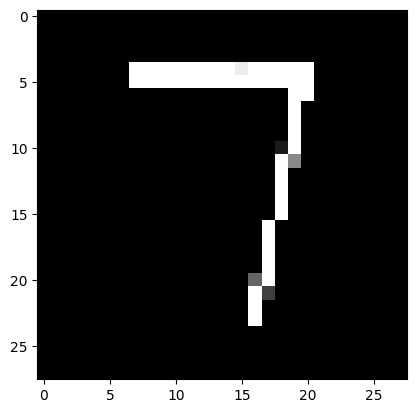

In [57]:
processed = preprocess_camera_image(r"C:\Users\dudyala guru sreekar\Downloads\7.jpeg")

plt.imshow(processed, cmap="gray")
print(np.sum(processed))
plt.show()

In [58]:
def predict_camera_digit(image_path, threshold=0.85):

    processed = preprocess_camera_image(image_path)
    
    if processed is None:
        return {"status": "no_digit_detected"}

    tensor = torch.tensor(processed, dtype=torch.float32)
    tensor = tensor.unsqueeze(0).unsqueeze(0)

    with torch.no_grad():
        output = model(tensor)
        probs = torch.softmax(output, dim=1)
        confidence, predicted = torch.max(probs, 1)

    confidence = confidence.item()
    predicted = predicted.item()

    if confidence < threshold:
        return {
            "status": "uncertain",
            "confidence": confidence
        }

    return {
        "status": "success",
        "digit": predicted,
        "confidence": confidence
    }

In [62]:
print(predict_camera_digit(r"C:\Users\dudyala guru sreekar\Downloads\7.jpeg"))

{'status': 'success', 'digit': 7, 'confidence': 0.9836224913597107}
